<a href="https://colab.research.google.com/github/cepulmano/ai-healthcare-medicine/blob/main/day2/predictiveanalytics/DiabetesPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Towards Using Data Mining and Machine Learning for Diabetes Risk Prediction

## RQ: How can we accurately predict diabetes risk using machine learning?

## Import the data and quick inspection

In [32]:
import numpy as np
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/cepulmano/ai-healthcare-medicine/refs/heads/main/day2/predictiveanalytics/diabetes_data.csv")
df.head()

,DiabetesOutcome,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,40,1,0,0,0,0,1,0,5,18,15,1,0,9,4,3
1,0,0,0,25,1,0,0,1,0,0,0,3,0,0,0,0,7,6,1
2,0,1,1,28,0,0,0,0,1,0,0,5,30,30,1,0,9,4,8
3,0,1,0,27,0,0,0,1,1,1,0,2,0,0,0,0,11,3,6
4,0,1,1,24,0,0,0,1,1,1,0,2,3,0,0,0,11,5,4


## Exploratory Data Analysis

In [33]:
# Descriptive statistics
df.describe()

,DiabetesOutcome,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [34]:
# Show the number of columns and rows in the dataset
df.shape

(253680, 19)

In [35]:
# Explore the distribution of the target variable
df['DiabetesOutcome'].value_counts()

,count
DiabetesOutcome,
0,218334
1,35346


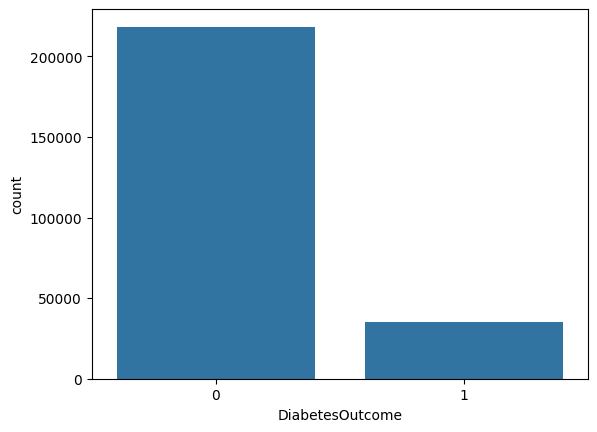

In [36]:
# Visualize the distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='DiabetesOutcome', data=df)
plt.show()

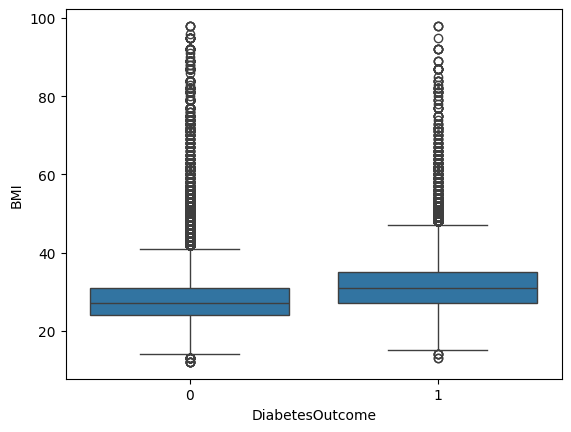

In [37]:
# Explore the relationship between different features and the target variable
# Example: Boxplot of BMI for diabetic and non-diabetic individuals
sns.boxplot(x='DiabetesOutcome', y='BMI', data=df)
plt.show()

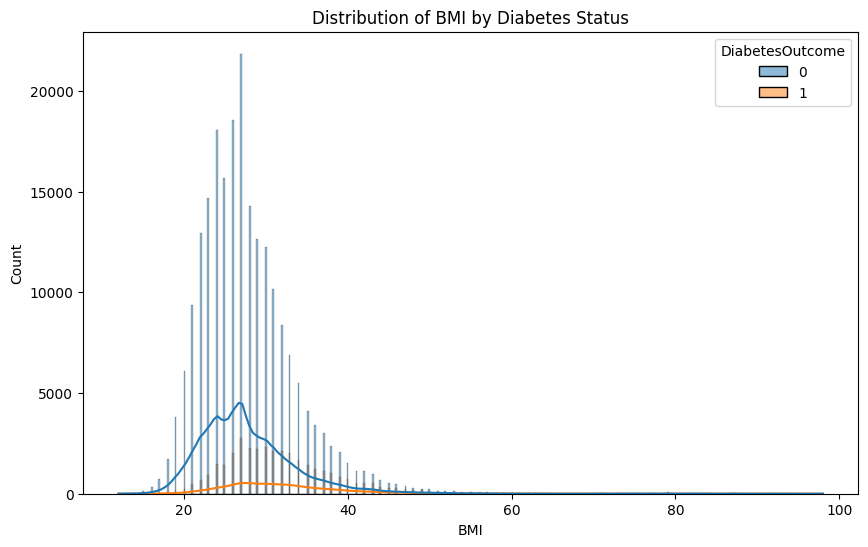

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='BMI', hue='DiabetesOutcome', kde=True)
plt.title('Distribution of BMI by Diabetes Status')
plt.show()


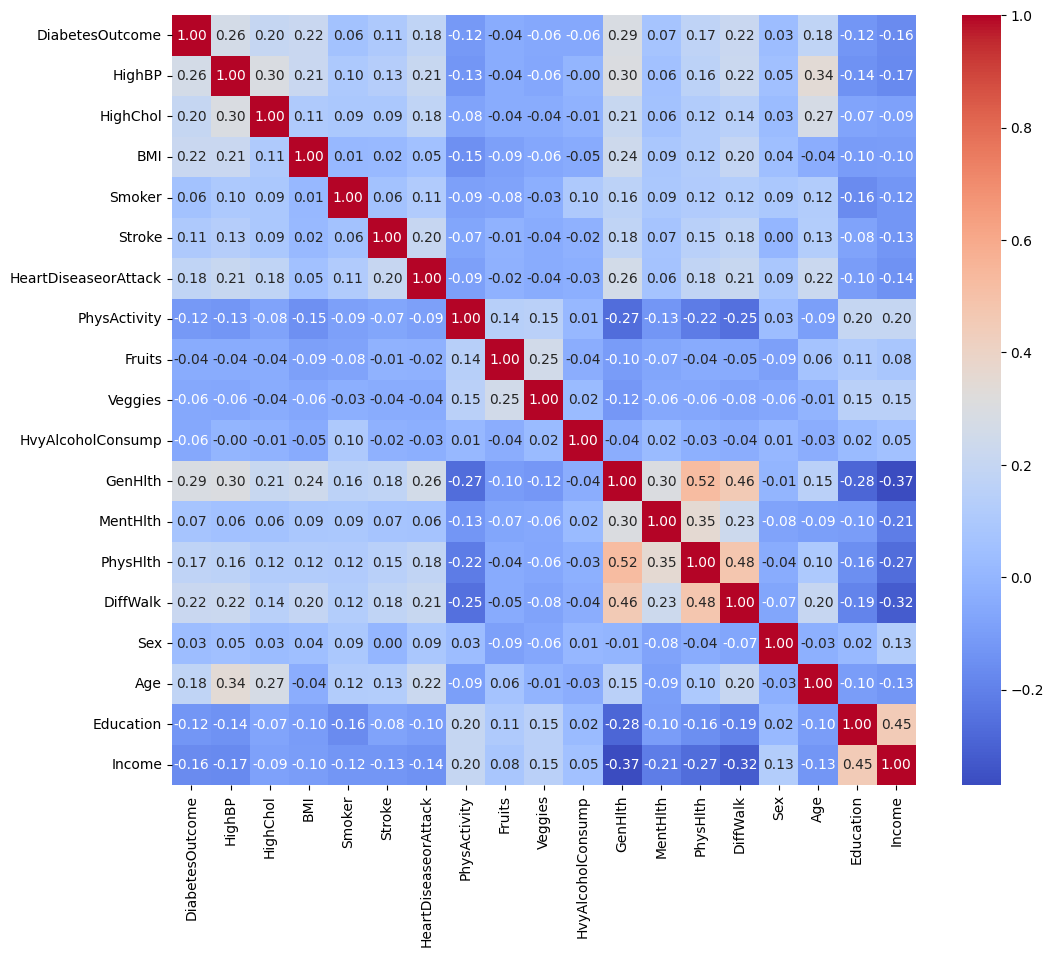

In [39]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Classification Using Multilayer Perceptrons Neural Networks on Imbalanced Dataset

### Split the data into training and test splits

In [47]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('DiabetesOutcome', axis=1)
y = df['DiabetesOutcome']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((202944, 18), (50736, 18), (202944,), (50736,))

### Standardize the dataset using Z-score normalization, setting mean=0 and standard deviation=1

In [61]:
from sklearn.preprocessing import StandardScaler

# Scale the features using StandardScaler
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train.describe()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17
count,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05,2.029440e+05
mean,1.148386e-17,8.682917e-18,3.221082e-18,-2.018428e-17,3.935322e-17,-9.400659e-18,3.501176e-18,-6.883313e-17,1.918645e-17,7.937167e-17,3.571200e-18,-6.144565e-18,1.470494e-18,-4.383473e-17,3.277101e-17,1.015341e-18,1.330447e-18,1.883633e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-8.653896e-01,-8.573786e-01,-2.475946e+00,-8.915719e-01,-2.056548e-01,-3.225563e-01,-1.765388e+00,-1.317300e+00,-2.076663e+00,-2.439711e-01,-1.415258e+00,-4.299017e-01,-4.871967e-01,-4.498448e-01,-8.871734e-01,-2.303520e+00,-4.105205e+00,-2.438122e+00
25%,-8.653896e-01,-8.573786e-01,-6.611649e-01,-8.915719e-01,-2.056548e-01,-3.225563e-01,5.664477e-01,-1.317300e+00,4.815417e-01,-2.439711e-01,-4.791360e-01,-4.299017e-01,-4.871967e-01,-4.498448e-01,-8.871734e-01,-6.658286e-01,-1.064778e+00,-5.079341e-01
50%,-8.653896e-01,-8.573786e-01,-2.074697e-01,-8.915719e-01,-2.056548e-01,-3.225563e-01,5.664477e-01,7.591287e-01,4.815417e-01,-2.439711e-01,-4.791360e-01,-4.299017e-01,-4.871967e-01,-4.498448e-01,-8.871734e-01,-1.075203e-02,-5.130201e-02,4.571600e-01
75%,1.155549e+00,1.166346e+00,3.974572e-01,1.121615e+00,-2.056548e-01,-3.225563e-01,5.664477e-01,7.591287e-01,4.815417e-01,-2.439711e-01,4.569858e-01,-1.606003e-01,-1.431950e-01,-4.498448e-01,1.127175e+00,6.443245e-01,9.621737e-01,9.397070e-01
max,1.155549e+00,1.166346e+00,1.052998e+01,1.121615e+00,4.862518e+00,3.100234e+00,5.664477e-01,7.591287e-01,4.815417e-01,4.098847e+00,2.329229e+00,3.609619e+00,2.952820e+00,2.222989e+00,1.127175e+00,1.626939e+00,9.621737e-01,9.397070e-01


### Build the model



In [67]:
from sklearn.neural_network import MLPClassifier

# Initialize and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10), max_iter=1000)
mlp.fit(X_train, y_train)

# Make predictions on the test set
predictions = mlp.predict(X_test)

### Evaluate the model

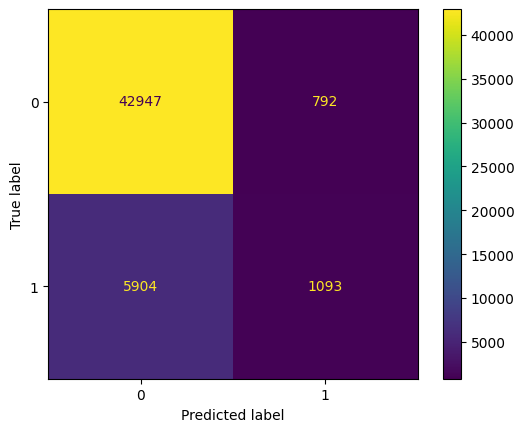

              precision    recall  f1-score   support

           0       0.88      0.98      0.93     43739
           1       0.58      0.16      0.25      6997

    accuracy                           0.87     50736
   macro avg       0.73      0.57      0.59     50736
weighted avg       0.84      0.87      0.83     50736



In [69]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Evaluate the model
cm = confusion_matrix(y_test,predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [0, 1])
cm_display.plot()
plt.show()
# About metrics: https://www.labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score

tn, fp, fn, tp = confusion_matrix(y_test,predictions).ravel().tolist()

print(classification_report(y_test, predictions)

**Recall (True Positive Rate)** - out of all the patients with Diabetes, how many did the model predict accurately?
$$ \frac{TP}{TP + FN} $$

**Precision (Positive Predictive Value)** - if the model predicts a patient as positive for Diabetes, what is the probability that the patient actually has Diabetes?
$$ \frac{TP}{TP + FP} $$

**False Positive Rate** - out of all the patients without Diabetes, how many did the model predict positively?
$$ \frac{FP}{FP + TN} $$

## Preprocessing

### Balance the Dataset Using Undersampling Method

In [41]:
from imblearn.under_sampling import RandomUnderSampler

# Separate features (X) and target variable (y)
X = df.drop('DiabetesOutcome', axis=1)
y = df['DiabetesOutcome']

# Initialize RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# Resample the dataset
X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Create a new balanced DataFrame
balanced_df = pd.DataFrame(X_resampled, columns=X.columns)
balanced_df['DiabetesOutcome'] = y_resampled

# Display class counts in the balanced dataset
print(balanced_df['DiabetesOutcome'].value_counts())

DiabetesOutcome
0    35346
1    35346
Name: count, dtype: int64


## Classification Using Multilayer Perceptrons Neural Networks on Balanced Dataset with 5-fold Cross Validation

In [42]:
from sklearn.model_selection import KFold

# Separate features (X) and target variable (y)
X = balanced_df.drop('DiabetesOutcome', axis=1)
y = balanced_df['DiabetesOutcome']

# Define the number of folds for cross-validation
n_splits = 5

# Initialize KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# Perform 5-fold cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Initialize and train the MLPClassifier
    mlp = MLPClassifier(hidden_layer_sizes=(10), max_iter=1000)
    mlp.fit(X_train, y_train)

    # Make predictions
    predictions = mlp.predict(X_test)

    # Evaluate the model and store the metrics
    report = classification_report(y_test, predictions, output_dict=True)
    accuracy_scores.append(report['accuracy'])
    precision_scores.append(report['macro avg']['precision'])
    recall_scores.append(report['macro avg']['recall'])
    f1_scores.append(report['macro avg']['f1-score'])

# Print the average performance metrics across all folds
# About metrics: https://www.labelf.ai/blog/what-is-accuracy-precision-recall-and-f1-score
print(f"Average Accuracy: {np.mean(accuracy_scores)}")
print(f"Average Precision: {np.mean(precision_scores)}")
print(f"Average Recall: {np.mean(recall_scores)}")
print(f"Average F1-score: {np.mean(f1_scores)}")


Average Accuracy: 0.7497877553871669
Average Precision: 0.7521339074722075
Average Recall: 0.7498033139364985
Average F1-score: 0.7492024400910171


## Build Model for Diabetes Risk Prediction System

In [43]:
# Separate features (X) and target variable (y)
X = balanced_df.drop('DiabetesOutcome', axis=1)
y = balanced_df['DiabetesOutcome']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10), max_iter=1000)
mlp.fit(X_train, y_train)

# Make predictions on the test set
predictions = mlp.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

tn, fp, fn, tp = confusion_matrix(y_test,predictions).ravel().tolist()
print(f"\nTrue Negative: {tn}")
print(f"False Positive: {fp}")
print(f"False Negative: {fn}")
print(f"True Positive: {tp}")

              precision    recall  f1-score   support

           0       0.78      0.70      0.74      7090
           1       0.73      0.80      0.76      7049

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139

[[4975 2115]
 [1392 5657]]

True Negative: 4975
False Positive: 2115
False Negative: 1392
True Positive: 5657


In [44]:
from sklearn.metrics import roc_auc_score

# Get probability predictions for the positive class (class 1)
probabilities = mlp.predict_proba(X_test)[:, 1]

# Calculate the AUROC score
auroc = roc_auc_score(y_test, probabilities)

print(f"AUROC Score: {auroc}")

AUROC Score: 0.8292625408159408


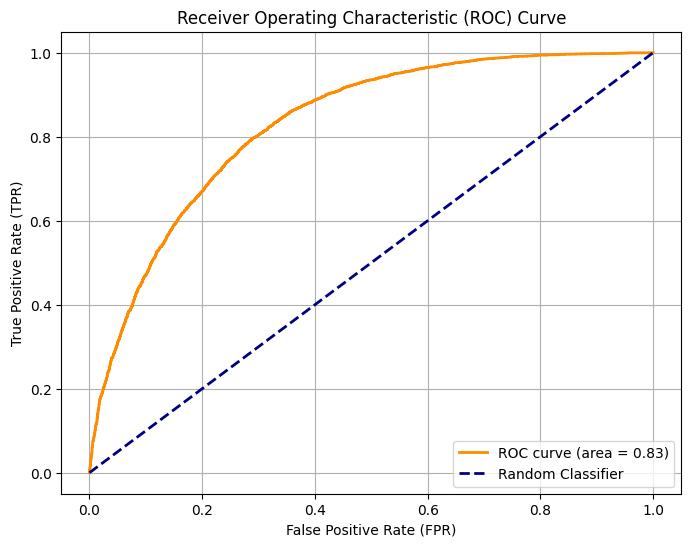

In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Predict Diabetes Risk using New Data

In [46]:
# New input data
new_data = pd.DataFrame({
    'HighBP': [1],
    'HighChol': [0],
    'BMI': [25],
    'Smoker': [0],
    'Stroke': [0],
    'HeartDiseaseorAttack': [0],
    'PhysActivity': [1],
    'Fruits': [1],
    'Veggies': [1],
    'HvyAlcoholConsump': [0],
    'GenHlth': [3],
    'MentHlth': [1],
    'PhysHlth': [0],
    'DiffWalk': [0],
    'Sex': [1],
    'Age': [45],
    'Education': [6],
    'Income': [8]
})

# Scale the new data using the same scaler used for training
new_data_scaled = scaler.transform(new_data)

# Make predictions on the new data
new_prediction = mlp.predict(new_data_scaled)
print(f"Prediction for new input: {new_prediction[0]}")

Prediction for new input: 0
